In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [6]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/Speech_emotion_recognition/RAVDESS/audio_speech_actors_01-24"

files = glob.glob(os.path.join(DATA_PATH, "Actor_*", "*.wav"))

print("Total audio files found:", len(files))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total audio files found: 1440


#Step 3: Emotion dictionary

In [8]:
emotion_dict = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

#Step 4: — Build dataframe

In [9]:
data = []

for file in files:
    filename = os.path.basename(file)
    parts = filename.replace(".wav", "").split("-")

    modality = parts[0]
    vocal_channel = parts[1]
    emotion_code = parts[2]
    intensity = parts[3]
    statement = parts[4]
    repetition = parts[5]
    actor = parts[6]

    data.append({
        "path": file,
        "filename": filename,
        "modality": modality,
        "vocal_channel": vocal_channel,
        "emotion_code": emotion_code,
        "emotion": emotion_dict[emotion_code],
        "intensity": intensity,
        "statement": statement,
        "repetition": repetition,
        "actor": int(actor)
    })

df = pd.DataFrame(data)
df.head()

,path,filename,modality,vocal_channel,emotion_code,emotion,intensity,statement,repetition,actor
0,/content/drive/MyDrive/Speech_emotion_recognit...,03-01-03-01-02-02-24.wav,03,01,03,happy,01,02,02,24
1,/content/drive/MyDrive/Speech_emotion_recognit...,03-01-02-02-02-02-24.wav,03,01,02,calm,02,02,02,24
2,/content/drive/MyDrive/Speech_emotion_recognit...,03-01-03-01-01-02-24.wav,03,01,03,happy,01,01,02,24
3,/content/drive/MyDrive/Speech_emotion_recognit...,03-01-01-01-02-01-24.wav,03,01,01,neutral,01,02,01,24
4,/content/drive/MyDrive/Speech_emotion_recognit...,03-01-01-01-01-01-24.wav,03,01,01,neutral,01,01,01,24


#Step 5 — Basic checks

In [10]:
print("--- Emotion Distribution ---")
print(df['emotion'].value_counts())

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

print("\nUnique actors:", df['actor'].nunique())

--- Emotion Distribution ---
emotion
happy        192
calm         192
fearful      192
sad          192
disgust      192
angry        192
surprised    192
neutral       96
Name: count, dtype: int64

--- Missing Values Check ---
path             0
filename         0
modality         0
vocal_channel    0
emotion_code     0
emotion          0
intensity        0
statement        0
repetition       0
actor            0
dtype: int64

Unique actors: 24


#Step 6: Emotion distribution graph

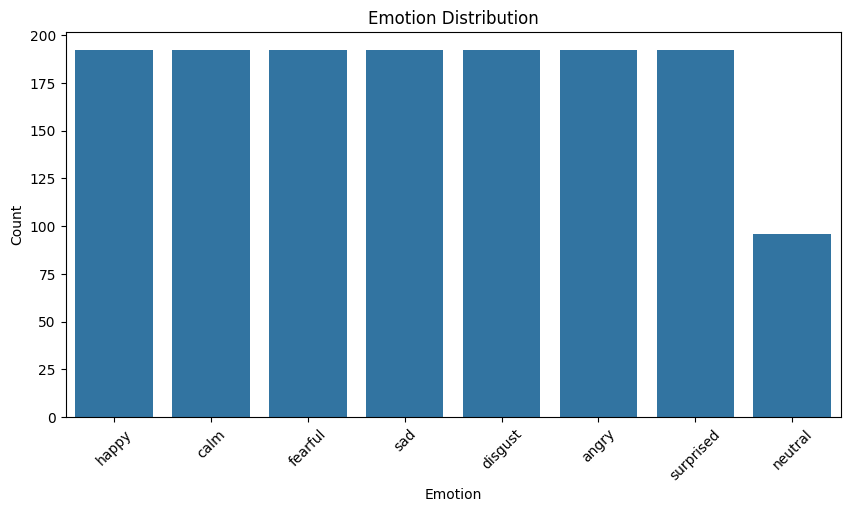

In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="emotion", order=df["emotion"].value_counts().index)
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#Step 7: one mel spectrogram sample

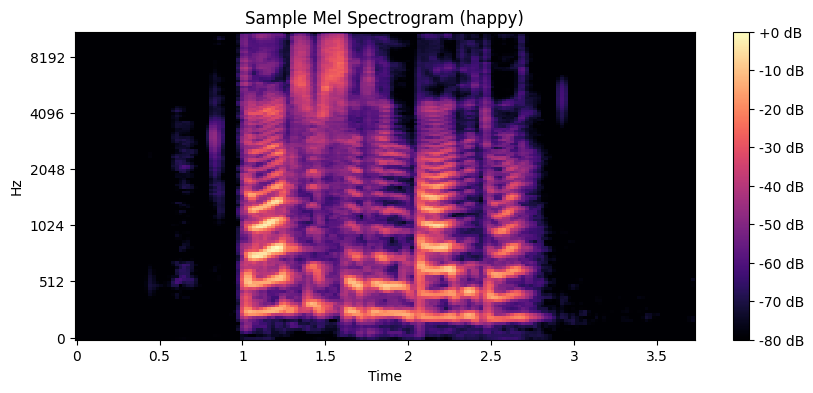

In [12]:
sample_path = df.loc[0, "path"]
sample_emotion = df.loc[0, "emotion"]

signal, sr = librosa.load(sample_path, sr=22050)
mel = librosa.feature.melspectrogram(y=signal, sr=sr)
mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Sample Mel Spectrogram ({sample_emotion})")
plt.show()

#Step 8 : Mel extraction function

In [13]:
def extract_mel(file_path, max_len=128):
    signal, sr = librosa.load(file_path, sr=22050)

    mel = librosa.feature.melspectrogram(y=signal, sr=sr)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    if mel_db.shape[1] > max_len:
        mel_db = mel_db[:, :max_len]
    else:
        pad_width = max_len - mel_db.shape[1]
        mel_db = np.pad(mel_db, pad_width=((0, 0), (0, pad_width)), mode='constant')

    return mel_db

#Step 9 — Build X and y

In [15]:
from tqdm import tqdm

X = []
y = []

for i in tqdm(range(len(df)), desc="Extracting Features"):
    file_path = df.loc[i, "path"]
    label = df.loc[i, "emotion"]

    feature = extract_mel(file_path)
    X.append(feature)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

Extracting Features: 100%|██████████| 1440/1440 [03:27<00:00,  6.95it/s]

X shape: (1440, 128, 128)
y shape: (1440,)


#Step 10 — Show one CNN input example

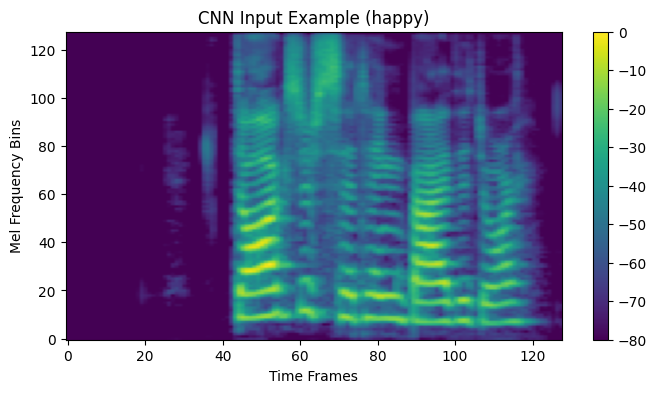

In [16]:
plt.figure(figsize=(8, 4))
plt.imshow(X[0], aspect='auto', origin='lower')
plt.colorbar()
plt.title(f"CNN Input Example ({y[0]})")
plt.xlabel("Time Frames")
plt.ylabel("Mel Frequency Bins")
plt.show()

#Step 11 — Encode labels


In [17]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Class order:", label_encoder.classes_)

#LabelEncoder → converts text labels like "happy" into numbers

Class order: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


#Step 12 — One-hot encoding

In [18]:
y_categorical = to_categorical(y_encoded)
print("y_categorical shape:", y_categorical.shape)

#to_categorical → converts class numbers into one-hot vectors for training

y_categorical shape: (1440, 8)


# Step 13 — Add channel dimension

In [19]:
if len(X.shape) == 3:
    X = X[..., np.newaxis]

print("Updated X shape:", X.shape)

Updated X shape: (1440, 128, 128, 1)


# Step 14 — Train-test split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1152, 128, 128, 1)
X_test shape: (288, 128, 128, 1)
y_train shape: (1152, 8)
y_test shape: (288, 8)


# Step 15 - Build CNN model


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(128,128,1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(8, activation='softmax')
])

#Step 16 - Compile

In [22]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,096 (12.61 MB)

 Trainable params: 3,305,096 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

#Step 17 — Train

In [23]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.1319 - loss: 9.9981 - val_accuracy: 0.1667 - val_loss: 2.0722
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.1580 - loss: 2.0542 - val_accuracy: 0.1632 - val_loss: 2.0561
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.2309 - loss: 1.9597 - val_accuracy: 0.3194 - val_loss: 1.8802
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.3264 - loss: 1.7907 - val_accuracy: 0.3438 - val_loss: 1.6893
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.4141 - loss: 1.6037 - val_accuracy: 0.4444 - val_loss: 1.5562
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.4740 - loss: 1.4003 - val_accuracy: 0.4826 - val_loss: 1.4286
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.4896 - loss: 1.3317 - val_accuracy: 0.4965 - val_loss: 1.3569
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.5616 - loss: 1.2133 - val_accuracy: 0.5208 - val_loss:

#Step 18 — Evaluate

In [24]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 241ms/step - accuracy: 0.5486 - loss: 1.3430
Test Accuracy: 0.5486111044883728


#Step 19 — Confusion matrix

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 233ms/step


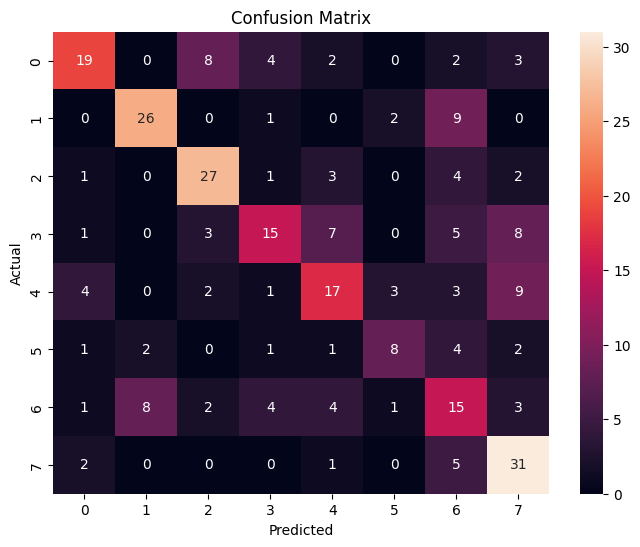

In [25]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 20 — Exporting the Model

In [26]:
import joblib
import os

SAVE_PATH = "/content/drive/MyDrive/Speech_emotion_recognition/models/"
os.makedirs(SAVE_PATH, exist_ok=True)

# Save the Keras model in .h5 format
model.save(SAVE_PATH + "cnn_model.h5")

# Save the label encoder
joblib.dump(label_encoder, SAVE_PATH + "label_encoder.pkl")
print("Saved to:", SAVE_PATH)


Saved to: /content/drive/MyDrive/Speech_emotion_recognition/models/
